# Stage 5 – Synthetic Anomaly Injection Benchmark

Evaluates how well the Stage 4b residual detector catches known anomalies.

**Approach:**
- Select clean building segments from the Stage 4b test period (Nov–Dec 2017)
- Inject 4 anomaly types and re-score using the calibrated per-building z-score
- Measure event-level recall, detection delay, and flagged-point fraction

Output: `stage5_benchmark_scorecard.parquet` — used in Phase 3 to tune the z-threshold.

**Caveat:** Injection modifies consumption values but leaves model input features (lags)
unchanged. Detection is measured against the original model predictions — an upper bound
on recall since in production the model would partially adapt via lag features during
sustained anomalies.

In [15]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

OUTPUTS_DIR      = Path('../../data/processed/anomaly-detection')
ANOMALIES_PATH   = OUTPUTS_DIR / 'stage4b_anomalies.parquet'
RESID_STATS_PATH = OUTPUTS_DIR / 'stage4b_resid_stats.parquet'
SCORECARD_OUT    = OUTPUTS_DIR / 'stage5_benchmark_scorecard.parquet'

ANOMALY_Z         = 3.0
MAD_SCALE         = 1.4826
MAD_FLOOR         = 1e-3
RANDOM_STATE      = 42
N_INJECT_PER_TYPE = 200
MAX_TRIES         = 50    # rejection-sampling retries per experiment
CLEAN_THRESHOLD   = 0.05  # buildings with < 5% pre-existing flag rate

rng = np.random.default_rng(RANDOM_STATE)

INJECTION_CONFIG = {
    'point_spike':   {'dur_lo': 1,  'dur_hi': 1,  'description': '1h spike at 3–10× normal consumption'},
    'level_shift':   {'dur_lo': 4,  'dur_hi': 48, 'description': '±20–50% sustained shift for 4–48h'},
    'flatline':      {'dur_lo': 6,  'dur_hi': 48, 'description': 'Consumption drops to 0 for 6–48h'},
    'gradual_drift': {'dur_lo': 24, 'dur_hi': 72, 'description': '+20–50% linear ramp over 24–72h'},
}

In [16]:
scored = pd.read_parquet(ANOMALIES_PATH)
scored['timestamp'] = pd.to_datetime(scored['timestamp'])
scored['building_id'] = scored['building_id'].astype(str)
scored = scored.sort_values(['building_id', 'timestamp']).reset_index(drop=True)

resid_stats = pd.read_parquet(RESID_STATS_PATH)
resid_stats_dict = {
    str(row['building_id']): (float(row['resid_median']), float(row['resid_mad']))
    for _, row in resid_stats.iterrows()
}

print(f'Scored rows      : {len(scored):,}')
print(f'Buildings        : {scored["building_id"].nunique():,}')
print(f'Test period      : {scored["timestamp"].min()} → {scored["timestamp"].max()}')
print(f'Overall flag rate: {scored["is_anomaly"].mean():.2%}')
print(f'Resid stats      : {len(resid_stats_dict):,} buildings')

Scored rows      : 2,031,624
Buildings        : 1,439
Test period      : 2017-11-01 00:00:00 → 2017-12-31 23:00:00
Overall flag rate: 6.13%
Resid stats      : 1,439 buildings


---
## 1. Clean Building Selection

In [17]:
bld_stats = (
    scored.groupby('building_id')['is_anomaly']
    .agg(flag_rate='mean', n_hours='count')
    .reset_index()
)
clean_mask = bld_stats['flag_rate'] < CLEAN_THRESHOLD
clean_buildings = bld_stats.loc[clean_mask, 'building_id'].tolist()

print(f'Total buildings          : {len(bld_stats):,}')
print(f'Clean (< {CLEAN_THRESHOLD:.0%} flag rate) : {len(clean_buildings):,}')
print(f'Median flag rate (clean) : {bld_stats.loc[clean_mask, "flag_rate"].median():.2%}')
print(f'Median flag rate (dirty) : {bld_stats.loc[~clean_mask, "flag_rate"].median():.2%}')

# Build per-building index for O(1) lookup during sampling
clean_scored = scored[scored['building_id'].isin(clean_buildings)].copy()
scored_by_building = {
    bld: grp.sort_values('timestamp').reset_index(drop=True)
    for bld, grp in clean_scored.groupby('building_id')
}
clean_bld_list = list(scored_by_building.keys())
print(f'\nBuildings indexed for sampling: {len(clean_bld_list):,}')

Total buildings          : 1,439
Clean (< 5% flag rate) : 815
Median flag rate (clean) : 1.84%
Median flag rate (dirty) : 9.15%

Buildings indexed for sampling: 815


---
## 2. Injection Functions

In [18]:
def make_residual_delta(
    injection_type: str,
    base_consumption: np.ndarray,
    duration_h: int,
) -> np.ndarray:
    """Return a delta array to add to residuals for the injection window."""
    n = len(base_consumption)

    if injection_type == 'point_spike':
        # Multiply consumption by 3–10×; residual increases by (mult-1) * consumption
        multiplier = rng.uniform(3.0, 10.0)
        return base_consumption * (multiplier - 1.0)

    elif injection_type == 'level_shift':
        # ±20–50% sustained shift
        direction = rng.choice([-1.0, 1.0])
        magnitude = rng.uniform(0.2, 0.5)
        return base_consumption * direction * magnitude

    elif injection_type == 'flatline':
        # Consumption collapses to 0; residual drops by current consumption
        return -base_consumption

    elif injection_type == 'gradual_drift':
        # Linear ramp to +20–50% over the window
        magnitude = rng.uniform(0.2, 0.5)
        ramp = np.linspace(0.0, magnitude, n)
        return base_consumption * ramp

    raise ValueError(f'Unknown injection type: {injection_type}')


def run_one_experiment(
    injection_type: str,
    duration_h: int,
    building_id: str,
    bld_data: pd.DataFrame,
) -> dict | None:
    """
    Rejection-sample a clean window, inject, and re-score.
    Returns a result dict or None if a clean window cannot be found.
    """
    n = len(bld_data)
    if n < duration_h + 1:
        return None

    stats = resid_stats_dict.get(building_id)
    if stats is None:
        return None
    resid_median, resid_mad = stats
    safe_mad = max(resid_mad * MAD_SCALE, MAD_FLOOR)

    for _ in range(MAX_TRIES):
        start_idx = int(rng.integers(0, n - duration_h))
        window = bld_data.iloc[start_idx : start_idx + duration_h]

        if window['is_anomaly'].any():
            continue  # dirty window; retry

        base_consume = window['consumption'].values.astype(float)
        base_resid   = window['residual'].values.astype(float)

        delta     = make_residual_delta(injection_type, base_consume, duration_h)
        new_resid = base_resid + delta
        new_z     = (new_resid - resid_median) / safe_mad
        flagged   = np.abs(new_z) > ANOMALY_Z

        detected = bool(flagged.any())
        delay_h  = int(np.argmax(flagged)) if detected else None

        return {
            'injection_type': injection_type,
            'building_id':    building_id,
            'start_time':     window.iloc[0]['timestamp'],
            'duration_h':     duration_h,
            'detected':       detected,
            'delay_h':        delay_h,
            'n_points':       duration_h,
            'n_flagged':      int(flagged.sum()),
            'max_abs_z':      float(np.abs(new_z).max()),
        }

    return None  # could not find a clean window within MAX_TRIES

---
## 3. Run Benchmark Experiments

In [19]:
results = []

for inj_type, cfg in INJECTION_CONFIG.items():
    dur_lo, dur_hi = cfg['dur_lo'], cfg['dur_hi']
    succeeded = 0
    attempted = 0
    max_attempts = N_INJECT_PER_TYPE * 10

    while succeeded < N_INJECT_PER_TYPE and attempted < max_attempts:
        attempted += 1
        bld_id     = clean_bld_list[int(rng.integers(len(clean_bld_list)))]
        duration_h = int(rng.integers(dur_lo, dur_hi + 1)) if dur_hi > dur_lo else dur_lo

        result = run_one_experiment(
            inj_type, duration_h, bld_id, scored_by_building[bld_id]
        )
        if result is not None:
            results.append(result)
            succeeded += 1

    status = 'OK' if succeeded == N_INJECT_PER_TYPE else f'WARN: only {succeeded}'
    print(f'{inj_type:20s}: {succeeded}/{N_INJECT_PER_TYPE} ({attempted} attempts)  [{status}]')

results_df = pd.DataFrame(results)
print(f'\nTotal experiments: {len(results_df):,}')
display(results_df.head())

point_spike         : 200/200 (200 attempts)  [OK]
level_shift         : 200/200 (201 attempts)  [OK]
flatline            : 200/200 (200 attempts)  [OK]
gradual_drift       : 200/200 (201 attempts)  [OK]

Total experiments: 800


,injection_type,building_id,start_time,duration_h,detected,delay_h,n_points,n_flagged,max_abs_z
0,point_spike,Bull_education_Dania,2017-12-12 03:00:00,1,True,0.0,1,1,152.937078
1,point_spike,Hog_education_Casandra,2017-11-06 05:00:00,1,True,0.0,1,1,34.642105
2,point_spike,Peacock_office_Naomi,2017-12-27 05:00:00,1,True,0.0,1,1,102.904200
3,point_spike,Robin_office_Zelma,2017-12-14 17:00:00,1,True,0.0,1,1,121.773384
4,point_spike,Rat_education_Marcos,2017-12-22 09:00:00,1,True,0.0,1,1,111.715055


---
## 4. Event-Level Results

=== Event-Level Benchmark Results ===



,injection_type,description,n_experiments,n_detected,event_recall,median_delay_h,median_max_z,median_frac_flagged
0,point_spike,1h spike at 3–10× normal consumption,200,200,1.000,0.0,101.73,1.0000
1,level_shift,±20–50% sustained shift for 4–48h,200,183,0.915,0.0,8.38,1.0000
2,flatline,Consumption drops to 0 for 6–48h,200,193,0.965,0.0,21.49,1.0000
3,gradual_drift,+20–50% linear ramp over 24–72h,200,176,0.880,15.0,7.49,0.5005


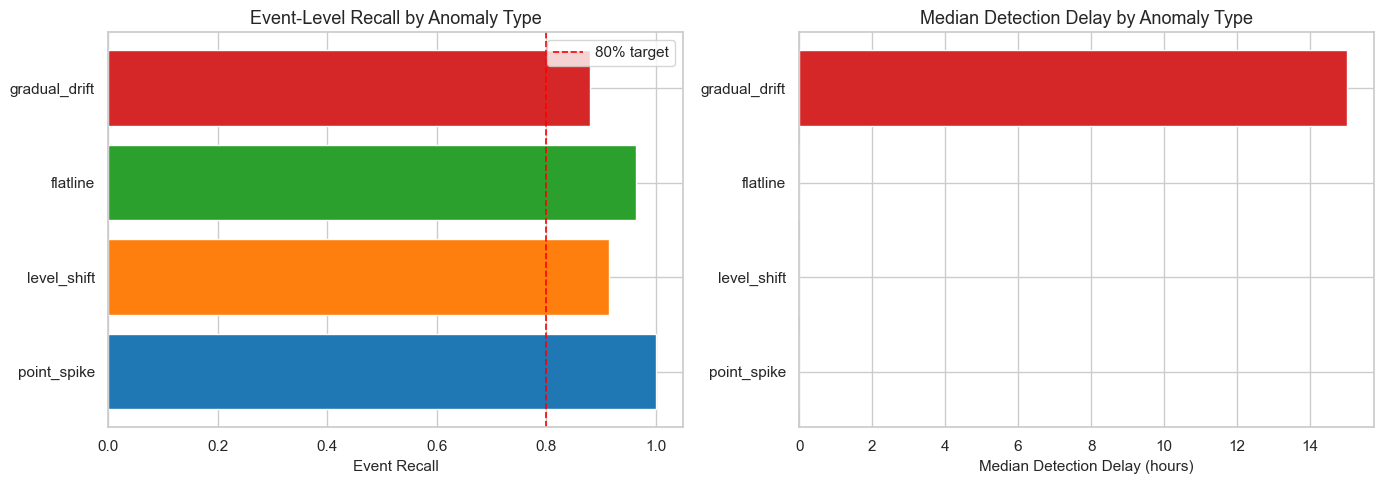


False-positive baseline (median flag rate of clean buildings): 1.84%


In [20]:
metrics_rows = []
for inj_type, cfg in INJECTION_CONFIG.items():
    grp = results_df[results_df['injection_type'] == inj_type]
    if len(grp) == 0:
        continue

    n_total    = len(grp)
    n_detected = int(grp['detected'].sum())
    recall     = n_detected / n_total
    det        = grp[grp['detected']]

    metrics_rows.append({
        'injection_type':      inj_type,
        'description':         cfg['description'],
        'n_experiments':       n_total,
        'n_detected':          n_detected,
        'event_recall':        round(recall, 4),
        'median_delay_h':      round(det['delay_h'].median(), 1) if len(det) else float('nan'),
        'median_max_z':        round(det['max_abs_z'].median(), 2) if len(det) else float('nan'),
        'median_frac_flagged': round((det['n_flagged'] / det['n_points']).median(), 4) if len(det) else float('nan'),
    })

metrics_df = pd.DataFrame(metrics_rows)
print('=== Event-Level Benchmark Results ===\n')
display(metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('tab10', len(metrics_rows))

axes[0].barh(metrics_df['injection_type'], metrics_df['event_recall'], color=colors)
axes[0].axvline(0.8, color='red', linestyle='--', linewidth=1.2, label='80% target')
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel('Event Recall')
axes[0].set_title('Event-Level Recall by Anomaly Type')
axes[0].legend()

delay_vals = metrics_df['median_delay_h'].fillna(0)
axes[1].barh(metrics_df['injection_type'], delay_vals, color=colors)
axes[1].set_xlabel('Median Detection Delay (hours)')
axes[1].set_title('Median Detection Delay by Anomaly Type')

plt.tight_layout()
plt.show()

# False positive baseline: median flag rate of clean buildings from Stage 4b scoring
clean_fp_rate = bld_stats.loc[clean_mask, 'flag_rate'].median()
print(f'\nFalse-positive baseline (median flag rate of clean buildings): {clean_fp_rate:.2%}')

---
## 5. Export Scorecard

In [21]:
results_df.to_parquet(SCORECARD_OUT, index=False)
print(f'Scorecard saved → {SCORECARD_OUT}')
print(f'Rows            : {len(results_df):,}')
print(f'Columns         : {list(results_df.columns)}')

print('\n=== Summary ===')
display(
    metrics_df[['injection_type', 'event_recall', 'median_delay_h', 'n_detected', 'n_experiments']]
    .to_string(index=False)
)

Scorecard saved → ..\..\data\processed\anomaly-detection\stage5_benchmark_scorecard.parquet
Rows            : 800
Columns         : ['injection_type', 'building_id', 'start_time', 'duration_h', 'detected', 'delay_h', 'n_points', 'n_flagged', 'max_abs_z']

=== Summary ===


'injection_type  event_recall  median_delay_h  n_detected  n_experiments\n   point_spike         1.000             0.0         200            200\n   level_shift         0.915             0.0         183            200\n      flatline         0.965             0.0         193            200\n gradual_drift         0.880            15.0         176            200'